# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from ciim.src.tf_activity.helper import retrieve_adata_bulk, retrieve_feature_data, retrieve_sig_stats
from ciim.src.common import prior_dir, plots_dir, datasets_e, datasets_a, datasets_all, cell_types, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, palette_minor_types
from ciim.src.utils.plots import plot_umap
from ciim.src.utils.util import get_genesets

to_save = f'{plots_dir}/umap/'
os.makedirs(to_save, exist_ok=True)

/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

# Stats of nets

In [ ]:
if False:
    n_target = {}
    net_dict = {}
    for cell_type in cell_types:
        net = get_consensus_net(cell_type=cell_type)
        net_dict[cell_type] = net
        n_target[cell_type] = net['target'].nunique()
    print(n_target)

    cell_type = 'MONO'
    net = net_dict[cell_type]
    c_outdegree = net.groupby('source').size().sort_values(ascending=False).head(20)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(2, 4))
    c_outdegree.plot(kind='barh')
    plt.xlabel('Source Gene')
    plt.title(f'Outdegree: {cell_type}')

# Overall corr of expression in aging

In [30]:
feature_type = 'gene_expression'
datasets = ['data1', 'data7_allTPs_jalil']
# - calculate corr
corr_results = {}
exp_results = {}
for cell_type in cell_types:
    exp_results[cell_type] = {}
    corr_results[cell_type] = {}
    for dataset in datasets:

        # - choose if gene expression or TF activity
        adata = retrieve_feature_data(dataset, cell_type, type='bulk', feature_type=feature_type)

        if adata.shape[0] < 2:
            continue
        
        if issparse(adata.X):
            adata.X = adata.X.todense()
        expr_df = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
        expr_df['age'] = adata.obs['age']
        expr_df = expr_df[(expr_df['age'] > 20) & (expr_df['age'] < 80)].copy()  # Filter out age ranges
        if True:
            expr_df['age_bin'] = (expr_df['age'].astype(int) // 2) * 2
            expr_df = expr_df.groupby('age_bin').median().drop(columns='age').sort_index()
        else:
            expr_df = expr_df.set_index('age').sort_index()
        if expr_df.shape[0] < 2:
            continue

        corr = expr_df.T.corr(method='spearman')  # Correlation between age bins
        corr_results[cell_type][dataset] = corr
        exp_results[cell_type][dataset] = expr_df


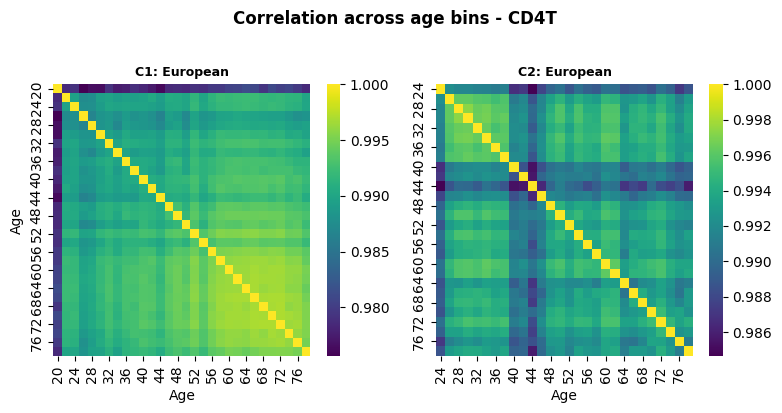

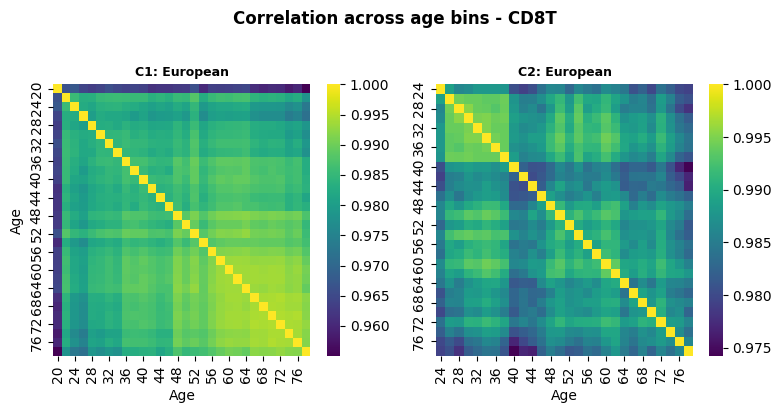

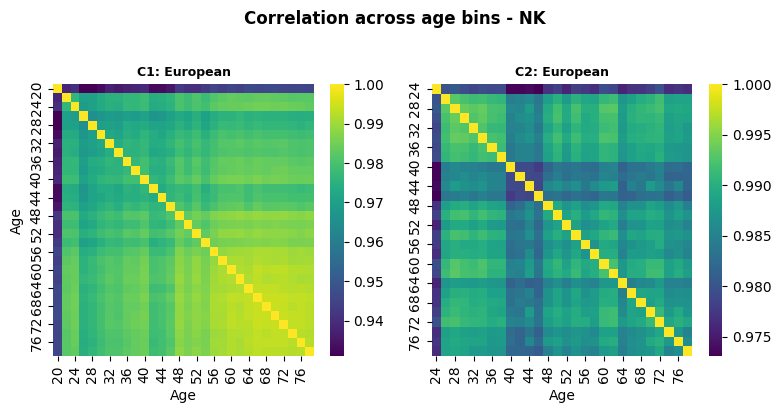

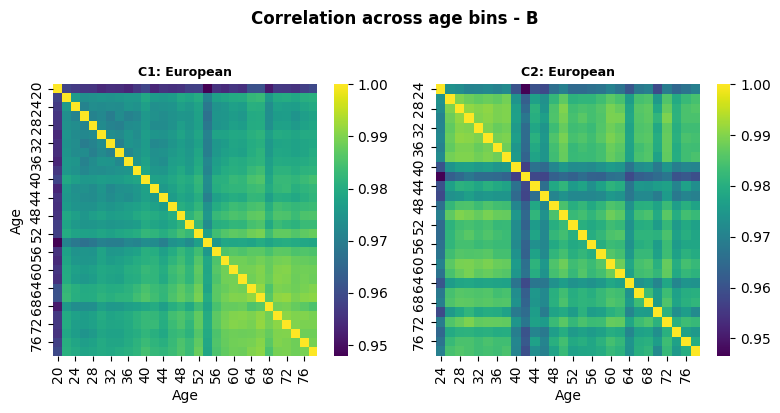

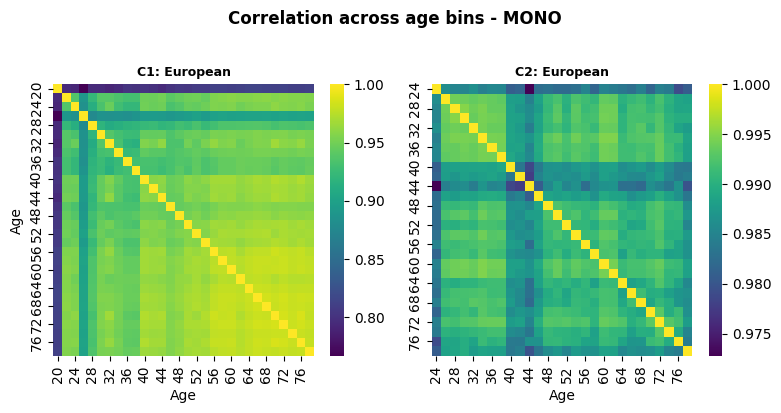

In [31]:
for cell_type, dataset_corrs in corr_results.items():
    if not datasets:
        continue
    n_cols = len(datasets)
    n_rows = 1
    fig, axes = plt.subplots(1, len(datasets), figsize=(4 * n_cols, 4), sharey=False)
    fig.suptitle(f'Correlation across age bins - {cell_type}', fontsize=12, fontweight='bold', y=1.02)
    for i, dataset in enumerate(datasets):
        corr = dataset_corrs[dataset]
        ax = axes[i]

        sns.heatmap(corr, ax=ax, cmap='viridis')
        # if i == 0:
        # sns.clustermap(corr, method='ward')
        ax.set_title(surrogate_names[dataset], fontsize=9, fontweight='bold')
        ax.set_xlabel('Age')
        if i == 0:
            ax.set_ylabel('Age')
        else:
            ax.set_ylabel('')


    plt.tight_layout()
    plt.show()

# ATAC

In [ ]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data6_CMtx.h5ad')

# Sub types umap

NameError: name 'datasets' is not defined

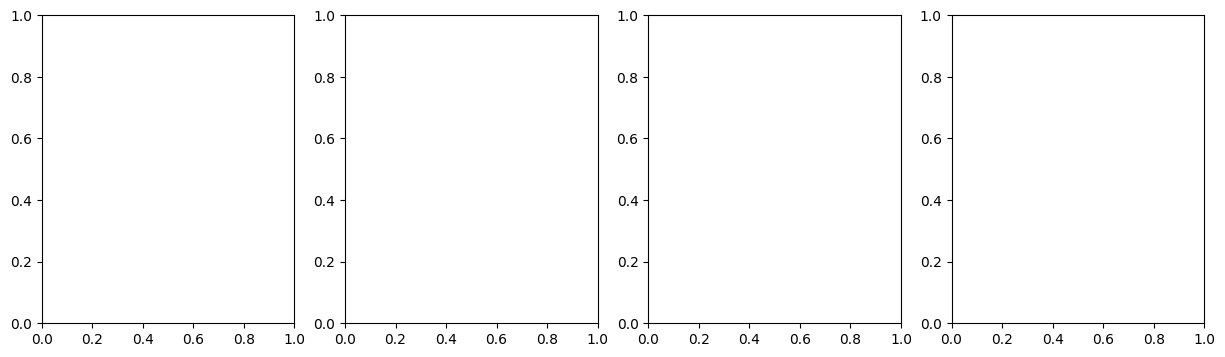

In [2]:
# - sub types
os.makedirs('../output/temp/umap/', exist_ok=True)
run_umap = False

for j, cell_type in enumerate(['CD8T', 'CD4T', 'MONO']):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for i, dataset in enumerate(datasets+v_datasets):
        ax = axes[i]
        if run_umap:
            adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_bulk_minor.h5ad', backed='r')
            adata = adata[adata.obs['Major_CT'] == cell_type].to_memory()
            sc.pp.highly_variable_genes(adata, n_top_genes=2000)
            sc.pp.pca(adata, use_highly_variable=True)  
            sc.pp.neighbors(adata, n_neighbors=15)  
            sc.tl.umap(adata) 
            adata.write(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        else:
            adata = ad.read_h5ad(f'../output/temp/umap/{cell_type}_{dataset}_bulk_minor.h5ad')
        plot_umap(adata, color='Sub_CT', ax=ax, s=5, X_label='X_pca', alpha=0.8, palette=palette_minor_types) 
        # sc.pl.umap(adata, color='Sub_CT', ax=ax, palette=palette_minor_types)
        
        if i != len(axes)-1:
            ax.get_legend().remove()
    # plt.tight_layout()

# Datasets stats

In [2]:
data_store = []
for dataset in datasets_all + ['Covid_50MHH']:
    adata = retrieve_adata_bulk(dataset)
    # if 'disease' in adata.obs.columns:
    #     adata = adata[adata.obs['disease']=='normal'].copy()
    n_cells = adata.obs['cell_count'].sum()
    n_donors = adata.obs['donor_id'].nunique()
    n_age_donors = adata.obs['age_donor'].nunique()
    data_store.append({'Dataset': dataset, 'Genes': adata.n_vars, 'Donors': n_donors, 'Samples (donors * age)': n_age_donors, 'Cells': n_cells})
df = pd.DataFrame(data_store)
df['Dataset'] = df['Dataset'].map(surrogate_names)
df

,Dataset,Genes,Donors,Samples (donors * age),Cells
0,C1: European,15275,981,981,1238460
1,C2: European,16479,166,313,1897627
2,C3: European,13472,61,61,527129
3,C5: European,13947,149,150,727135
4,C4: Korean,15820,165,165,352452
5,C4: Japanese,15394,148,148,281368
6,C6: Covid,13309,42,42,152344


In [3]:
df['Cells'].sum(), df['Genes'].sum(), df['Donors'].sum(), df['Samples (donors * age)'].sum()

(5176515, 103696, 1712, 1860)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


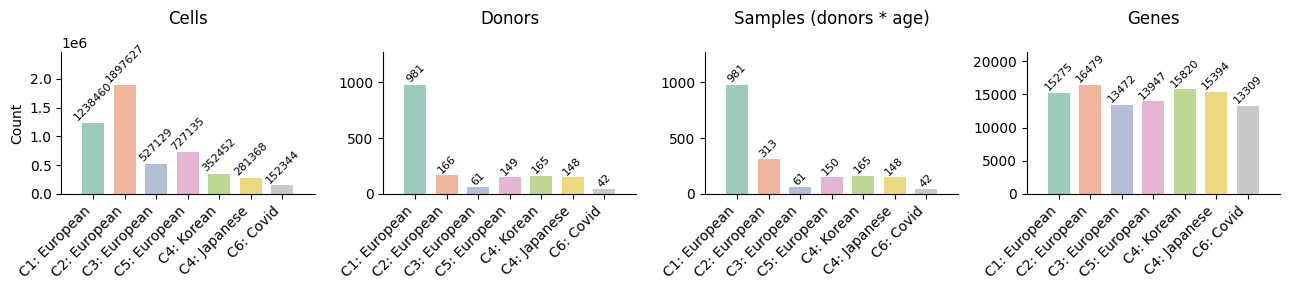

In [4]:
from ciim.src.common import palette_datasets

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Dataset"], var_name="Metadata", value_name="Count")

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for i, metadata in enumerate(['Cells', 'Donors', 'Samples (donors * age)', 'Genes']):
    ax = axes[i]
    
    # Create bar plot
    sns.barplot(data=df, x='Dataset', y=metadata, alpha=.7, ax=ax, hue='Dataset', width=.7, palette=palette_datasets_pretty, legend=False)
    
    # Annotate bars with values (rotated 45 degrees)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2,  # X position
                p.get_height(),  # Y position (top of bar)
                f'{int(p.get_height())}',  # Text label
                ha='center', va='bottom', fontsize=8, rotation=45)  # Rotate 45 degrees

    # Formatting
    ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.1, y=0.3)
    
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.legend().remove()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

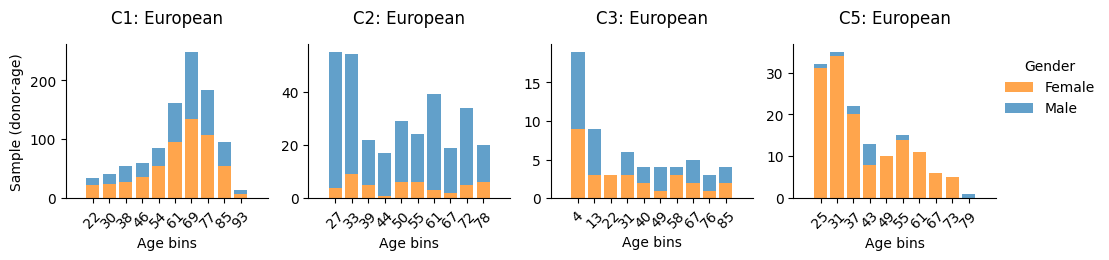

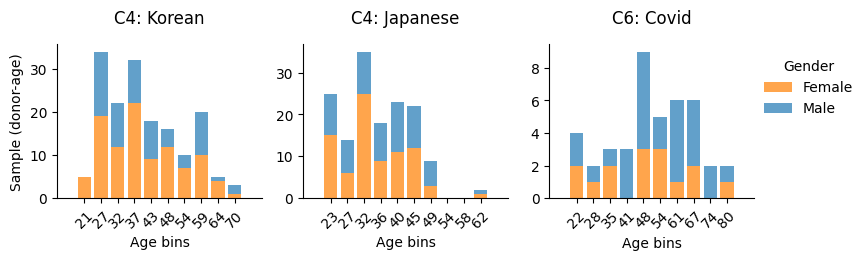

In [5]:
gender_samples = {}
def race_plot(race):
    if race == 'european':
        datasets = datasets_e
    else:
        datasets = datasets_a + ['Covid_50MHH']
    fig, axes = plt.subplots(1, len(datasets), figsize=(3*len(datasets), 2), sharey=False)
    for i, dataset in enumerate(datasets):
        adata = retrieve_adata_bulk(dataset)
        
        df = adata.obs.copy()
        df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
        df = df.drop_duplicates(subset=['donor_id', 'age'])

        # Count occurrences of each sex within each age group
        df_count = df.groupby(['age', 'sex']).size().reset_index(name='count')
        gender_samples[dataset] = {sex: df_count[df_count['sex']==sex]['count'].sum() for sex in ['Male', 'Female']}

        # Pivot data for stacking
        df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

        # Plot stacked bar chart
        df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
        df_binned = df_pivot.groupby('binned').sum() 
        df_binned.plot(kind='bar', stacked=True, ax=axes[i], color=palette_genders, alpha=0.7, width=.8)


        axes[i].set_xlabel("Age bins")
        axes[i].set_ylabel("Sample (donor-age)" if i == 0 else "")  
        axes[i].set_title(surrogate_names[dataset], pad=15)
        bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
        axes[i].set_xticklabels(bin_midpoints)

        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        x_min, x_max = axes[i].get_xlim()
        axes[i].set_xlim(x_min - 1, x_max + 1) 
        
        axes[i].get_legend().remove()
    axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')

    plt.show()
race_plot('european')
race_plot('asian')

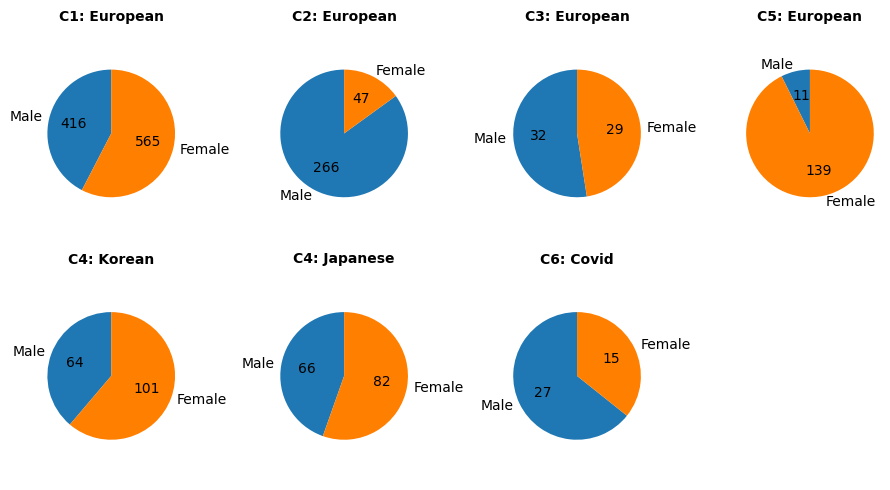

In [6]:

# Plotting pie charts
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
axes = axes.flatten()

for i, (dataset, counts) in enumerate(gender_samples.items()):
    labels = list(counts.keys())
    sizes = list(counts.values())
    # axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=palette_genders.values())
    axes[i].pie(sizes, labels=labels, autopct=lambda p: f'{int(round(p * sum(sizes) / 100))}', startangle=90, colors=palette_genders.values())
    
    axes[i].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    axes[i].set_title(surrogate_names[dataset], fontsize=10, weight='bold')

# Hide any unused subplots
for j in range(len(gender_samples), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Disease

Text(0.5, 1.0, 'C5: European')

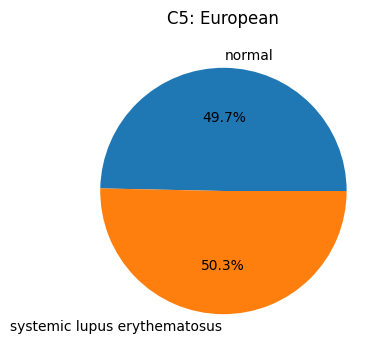

In [8]:
dataset = 'SLE_European'
adata = retrieve_adata_bulk(dataset)
race_info = adata.obs.groupby('disease')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['disease'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

Text(0.5, 1.0, 'C6: Covid')

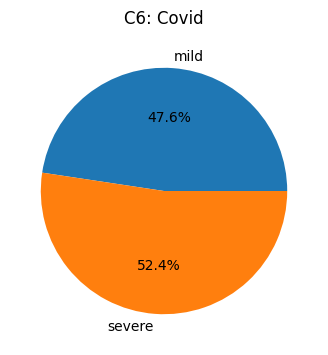

In [9]:
dataset = 'Covid_50MHH'
adata = retrieve_adata_bulk(dataset)

race_info = adata.obs.groupby('Max_WHO_Group')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['Max_WHO_Group'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

In [8]:
adata.obs.groupby(['cell_type', 'Max_WHO_Group']).size()

cell_type  Max_WHO_Group
B          mild             20
           severe           22
CD4T       mild             20
           severe           22
CD8T       mild             20
           severe           22
MONO       mild             20
           severe           22
NK         mild             20
           severe           22
dtype: int64

# Minor types rations

In [10]:
obs_dict = {dataset: ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets_all}

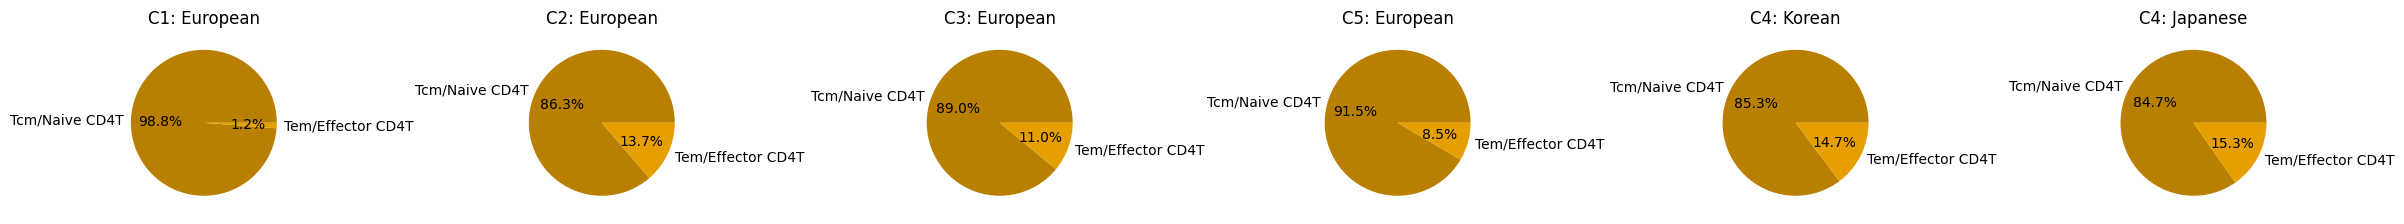

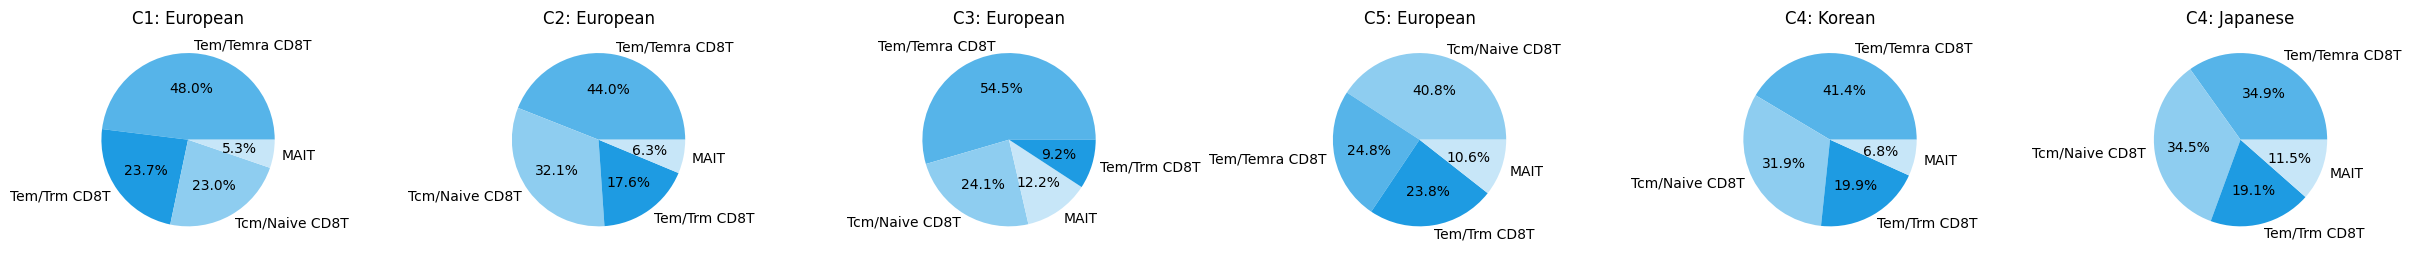

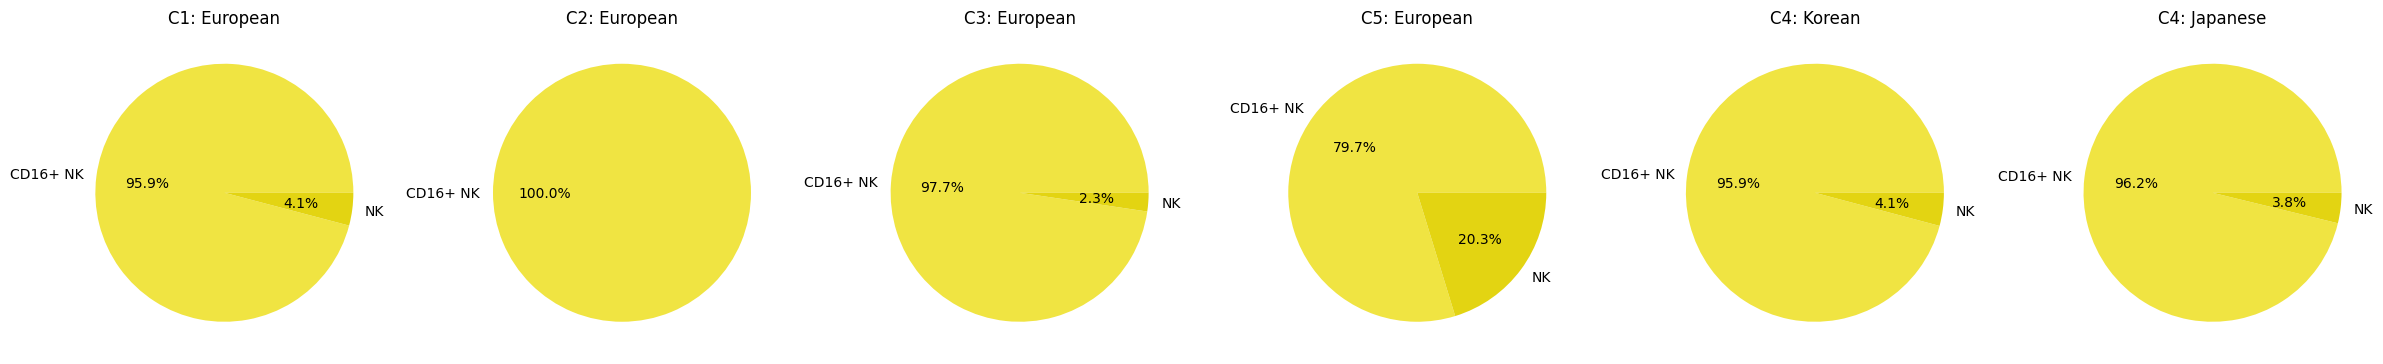

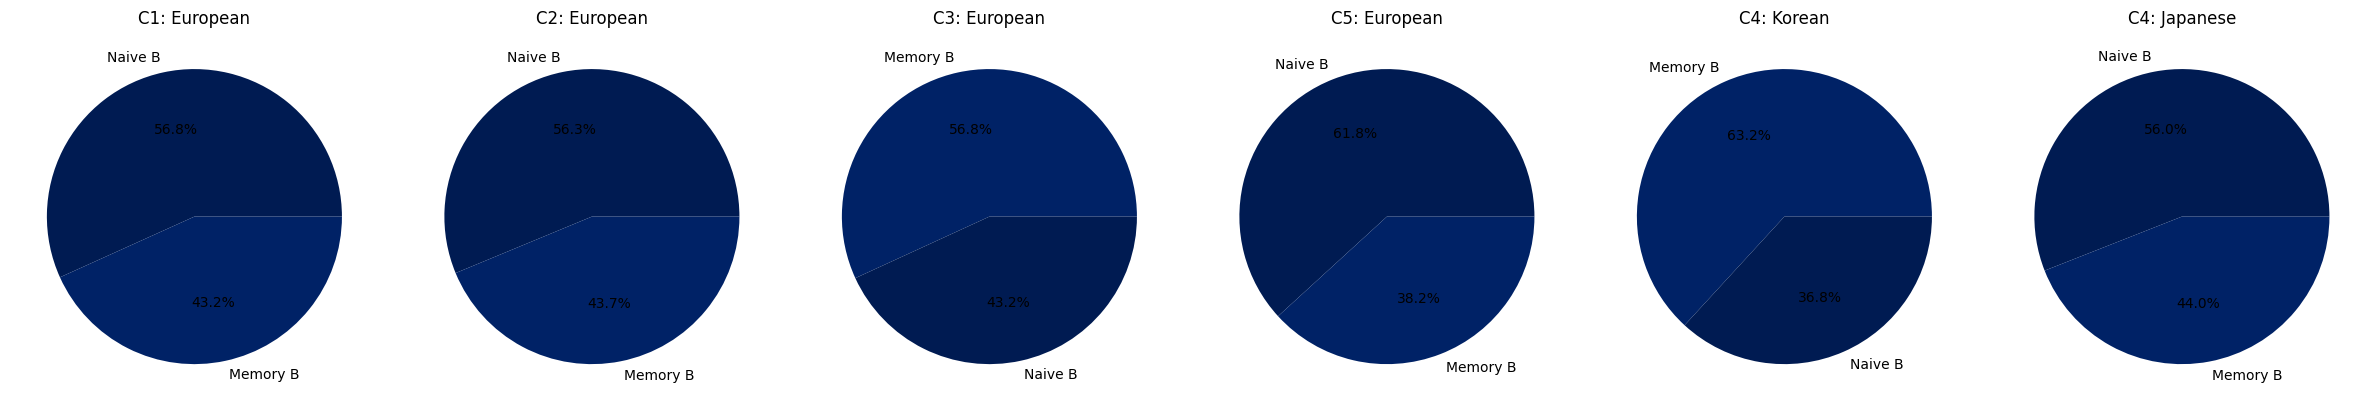

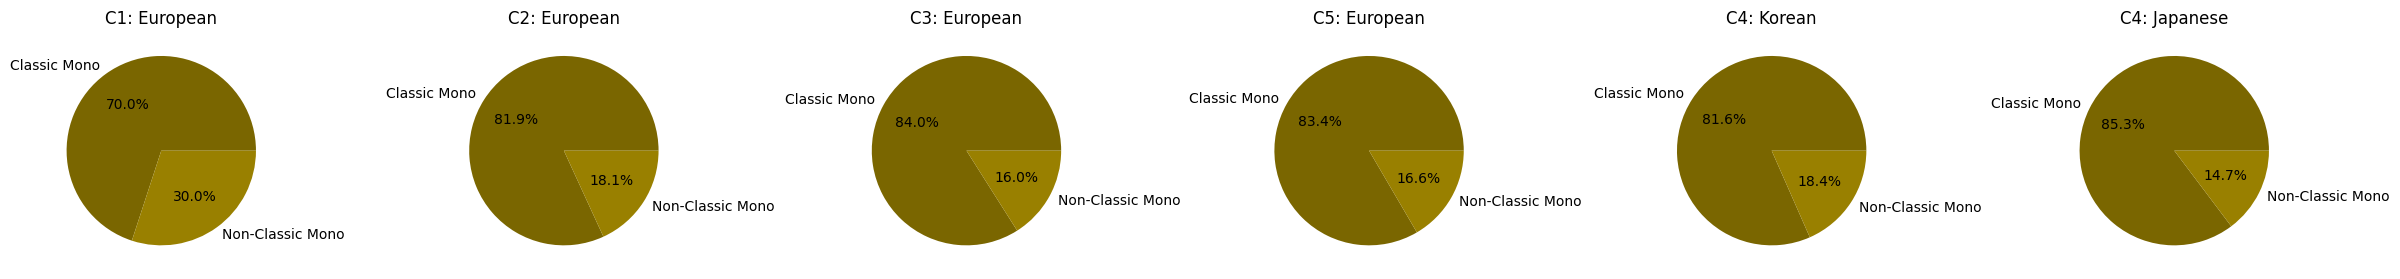

In [27]:
from ciim.src.common import minor_cell_types, palette_minor_types_pretty, mapping_minor_2_major, surrogate_names
def pieplot(df, ax):
    """Create a pie chart with mapped colors."""
    df = df.to_frame(name='count')  # Convert Series to DataFrame
    df.index.name = 'cell_type'
    colors = [palette_minor_types_pretty[cell] if cell in palette_minor_types_pretty else "#cccccc" for cell in df.index]
    df.plot(kind='pie', y='count', autopct='%1.1f%%', colors=colors, ax=ax, legend=False)
    ax.set_ylabel('')
datasets = datasets_all
for j, cell_type in enumerate(cell_types):
    fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 4))
    for i, dataset in enumerate(datasets):
        obs = obs_dict[dataset]
        obs = obs[obs['Sub_CT'].isin(minor_cell_types)] # keep only the valid names
        obs = obs[obs['Major_CT'] == cell_type]
        obs['Sub_CT'] = obs['Sub_CT'].astype(str)
        obs['Sub_CT'] = obs['Sub_CT'].apply(lambda name: surrogate_names.get(name, name))

        cell_type_counts = obs['Sub_CT'].value_counts()
        ax = axes[i]
        pieplot(cell_type_counts, ax)
        ax.set_title(surrogate_names[dataset])
    plt.tight_layout()

# Minor cell types frequency

In [39]:
def calculate_freq(obs):
    # - calculate frequency 
    obs['Sub_CT'] = obs['Sub_CT'].astype(str)
    subct_counts = obs.groupby(['donor_id', 'Sub_CT']).size().reset_index(name='count')
    total_counts = obs.groupby('donor_id').size().reset_index(name='total')
    freq = subct_counts.merge(total_counts, on='donor_id')
    freq['ratio'] = freq['count'] / freq['total']
    metadata_cols = ['donor_id', 'age', 'age_group']
    metadata = obs[metadata_cols].drop_duplicates()
    freq = freq.merge(metadata, on='donor_id', how='left')
    return freq

freq_store = []
for j, cell_type in enumerate(cell_types):
    for i, dataset in enumerate(datasets_all):
        obs = obs_dict[dataset]
        obs = obs[obs['cell_type'] == cell_type]
        freq = calculate_freq(obs)
        freq['dataset'] = dataset
        freq_store.append(freq)
freq_df = pd.concat(freq_store)

,donor_id,Sub_CT,count,total,ratio,age,age_group,dataset
126,1340,Naive_B,0,0,NaN,NaN,NaN,SLE_European
222,1811,Naive_B,0,0,NaN,NaN,NaN,SLE_European


['Tem_Trm_CD8', 'Tem_Temra_CD8', 'Tcm_Naive_CD8', 'MAIT']


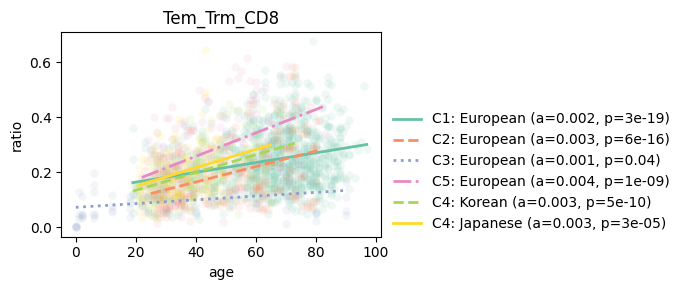

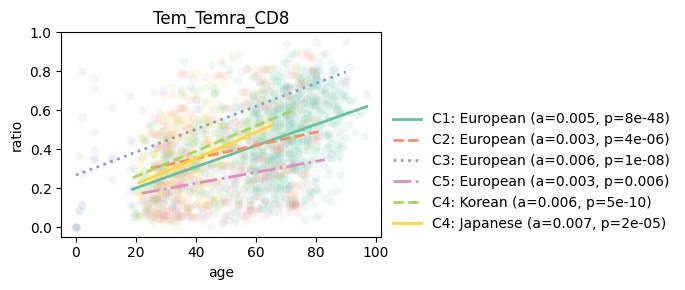

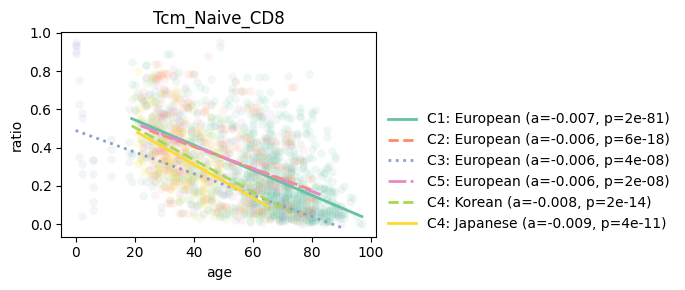

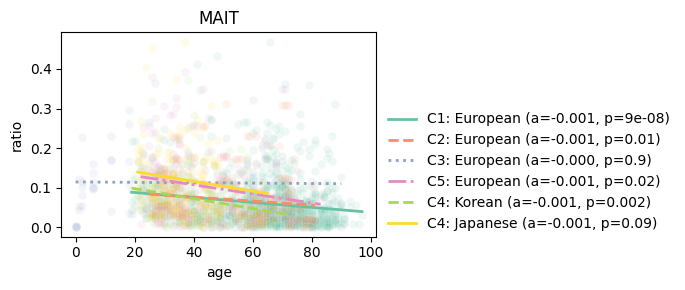

In [52]:
import statsmodels.api as sm
from scipy import stats

from ciim.src.common import mapping_major_2_minor

line_styles = ['-', '--', ':', '-.', '--']
line_styles+=line_styles
for cell_type in ['CD8T']:
    subtypes = mapping_major_2_minor[cell_type]
    print(subtypes)
    for i, subtype in enumerate(subtypes):
        fig, ax = plt.subplots(1, 1, figsize=(7, 3))
        # ax = axes[i]
        for j, dataset in enumerate(freq_df['dataset'].unique()):
            df_sub = freq_df[(freq_df['dataset'] == dataset)&(freq_df['Sub_CT'] == subtype)]
            sns.scatterplot(data=df_sub, x='age', y='ratio', color=palette_datasets[dataset], alpha=0.1, label=None, ax=ax)
            # Linear model
            X = sm.add_constant(df_sub['age'])
            df_sub = df_sub[~df_sub['ratio'].isna()]
            df_sub = df_sub[np.isfinite(df_sub['ratio'])]
            # Combine X and y into a single DataFrame temporarily
            df_model = pd.concat([X, df_sub['ratio']], axis=1)

            # Drop rows with any NaN or inf values
            df_model = df_model[np.isfinite(df_model).all(axis=1)]

            # Separate X and y again
            X_clean = df_model.drop(columns='ratio')
            y_clean = df_model['ratio']

            # Now fit the model
            model = sm.OLS(y_clean, X_clean).fit()
            slope = model.params['age']
            pval = model.pvalues['age']
            
            # Predict line
            x_vals = df_sub['age'].sort_values()
            y_vals = model.predict(sm.add_constant(x_vals))
            
            ax.plot(x_vals, y_vals, linestyle=line_styles[j], color=palette_datasets[dataset], label=f"{surrogate_names[dataset]} (a={slope:.3f}, p={pval:.1g})", linewidth=2)
        ax.legend(loc=(1.02, 0), frameon=False)
        ax.set_title(subtype)
        plt.tight_layout()

# GRNs

## Compare nets


In [6]:
from ciim.src.tf_activity.helper import retrieve_net
if True:
    net_store = []
    for cell_type in cell_types:
        for dataset in datasets_all:
            net = retrieve_net(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            print(f'net: {cell_type} {dataset} ', net.shape)
            net_store.append(net)
    nets_all = pd.concat(net_store)


net: CD4T data1  (6752, 6)
net: CD4T data7_allTPs_jalil  (18729, 6)
net: CD4T data12  (22545, 6)
net: CD4T SLE_European  (4572, 6)
net: CD4T data13_Korean  (27053, 6)
net: CD4T data13_Japanese  (20248, 6)
net: CD8T data1  (12668, 6)
net: CD8T data7_allTPs_jalil  (46533, 6)
net: CD8T data12  (42502, 6)
net: CD8T SLE_European  (9003, 6)
net: CD8T data13_Korean  (116056, 6)
net: CD8T data13_Japanese  (82905, 6)
net: NK data1  (2421, 6)
net: NK data7_allTPs_jalil  (11216, 6)
net: NK data12  (6284, 6)
net: NK SLE_European  (1794, 6)
net: NK data13_Korean  (14277, 6)
net: NK data13_Japanese  (7707, 6)
net: B data1  (153720, 6)
net: B data7_allTPs_jalil  (34747, 6)
net: B data12  (25847, 6)
net: B SLE_European  (5917, 6)
net: B data13_Korean  (46499, 6)
net: B data13_Japanese  (22596, 6)
net: MONO data1  (85498, 6)
net: MONO data7_allTPs_jalil  (105431, 6)
net: MONO data12  (77013, 6)
net: MONO SLE_European  (23746, 6)
net: MONO data13_Korean  (213931, 6)
net: MONO data13_Japanese  (225881, 6

['C4: Korean', 'C4: Japanese', 'C2: European', 'C3: European', 'C1: European', 'C5: European']


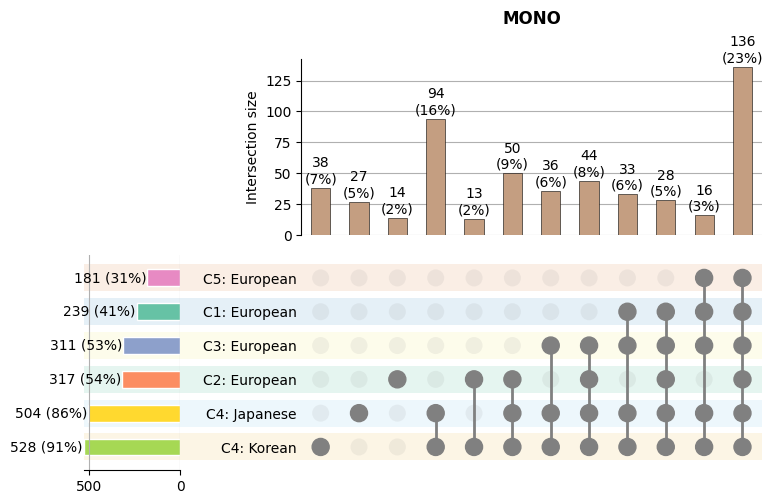

In [9]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
if True:
    to_show='source'

    if to_show=='source':
        min_subset_size=10
        min_degree=1
    if to_show=='target':
        min_subset_size=10
        min_degree=2
    if to_show=='edge':
        min_subset_size=8000
        min_degree=2


    for cell_type in ['MONO']:
        nets = nets_all[nets_all['cell_type']==cell_type]
        df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

        interaction_df = create_interaction_df(df_dict)
        interaction_df.columns = interaction_df.columns.map(surrogate_names)
        aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
        plt.title(cell_type, y=1.15, weight='bold')

# Whether the higher network density of C4 is driven due to female dominance 

# Open genes aging genes

In [2]:
from ciim.src.utils.util import get_opengenes_sets
reverse_map = get_opengenes_sets()

In [3]:
gene_counts = {k: len(v) for k, v in reverse_map.items()}
gene_counts_series = pd.Series(gene_counts)
gene_counts_series = gene_counts_series.sort_values(ascending=False)
gene_counts_series

Transcriptional alterations                                 444
Intercellular communication impairment                      204
Nuclear DNA instability                                     201
Degradation of proteolytic systems                          193
Accumulation of reactive oxygen species                     165
Sterile inflammation                                        131
Impairment of the mitochondrial integrity and biogenesis    110
Alterations in histone modifications                         83
Chromatin remodeling                                         61
Changes in the extracellular matrix structure                59
INS/IGF-1 pathway dysregulation                              54
Stem cell exhaustion                                         49
Senescent cells accumulation                                 48
Disabled macroautophagy                                      37
Telomere attrition                                           35
TOR pathway dysregulation               

Text(0.5, 1.0, 'Open genes stats')

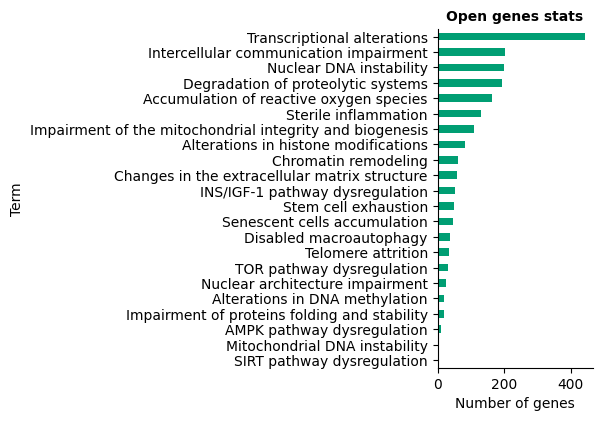

In [4]:
fig, ax = plt.subplots(figsize=(2, max(2, len(gene_counts_series) * 0.2)))
gene_counts_series.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of genes')
ax.set_ylabel('Term')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f'Open genes stats', weight='bold', fontsize=10)

## Compare it to our sig TFs

In [ ]:
gg = reverse_map['Transcriptional alterations']

In [5]:
# - number of reported genes in our significant stats
cell_type = 'CD8T'
stats_sig = retrieve_sig_stats()
unique_tfs = stats_sig[stats_sig['cell_type']==cell_type]['tf'].unique()

common_tfs = np.intersect1d(unique_tfs, gg)
print('Number of common TFs:', len(common_tfs))

Number of common TFs: 53


In [9]:
from ciim.src.tf_activity.helper import retrieve_sig_net
targets = retrieve_sig_net(cell_type = cell_type)['target'].unique()
common_genes = np.intersect1d(targets, gg)
print('Number of common genes:', len(common_genes), ' among ', len(targets), ' targets in the network')

Number of common genes: 75  among  1713  targets in the network
